In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [3]:
import polars as pl

In [4]:
pl.Config.set_tbl_rows(50)          
pl.Config.set_fmt_str_lengths(100)

polars.config.Config

In [5]:
from src.eda_cfpb import InitialEda

In [6]:
ie=InitialEda('../data/raw/complaints.csv')


In [7]:
ie.load_data()

Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Incorrect information on your report""","""Information belongs to someone else""",null,null,"""Experian Information Solutions Inc.""","""FL""","""32092""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195687
"""2025-06-20""","""Debt collection""","""Telecommunications debt""","""Attempts to collect debt not owed""","""Debt is not yours""",null,"""Company can't verify or dispute the facts in the complaint""","""Eastern Account Systems of Connecticut, Inc.""","""FL""","""342XX""",null,null,"""Web""","""2025-06-20""","""Closed with explanation""","""Yes""",null,14195688
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Improper use of your report""","""Reporting company used your report improperly""",null,null,"""TRANSUNION INTERMEDIATE HOLDINGS, INC.""","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195689
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Improper use of your report""","""Reporting company used your report improperly""",null,null,"""Experian Information Solutions Inc.""","""AZ""","""85225""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195690
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Incorrect information on your report""","""Account status incorrect""",null,null,"""Experian Information Solutions Inc.""","""IL""","""60628""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195692
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Incorrect information on your report""","""Information belongs to someone else""",null,null,"""TRANSUNION INTERMEDIATE HOLDINGS, INC.""","""TX""","""77568""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195711
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Improper use of your report""","""Reporting company used your report improperly""",null,null,"""Experian Information Solutions Inc.""","""NV""","""89107""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195715
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Improper use of your report""","""Reporting company used your report improperly""",null,null,"""Experian Information Solutions Inc.""","""GA""","""30058""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195718
"""2025-06-20""","""Credit reporting or other personal consumer reports""","""Credit reporting""","""Incorrect information on your report""","""Account information incorrect""",null,null,"""Experian Information Solutions Inc.""","""CA""","""92324""",null,null,"""Web""","""2025-06-20""","""In progress""","""Yes""",null,14195719


In [8]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64)])


The missing data

shape: (18, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 235295   │
│ Issue                        ┆ 6        │
│ Sub-issue    

In [9]:
ie.analyze_product_distribution()


Complaint Distribution by Product:
shape: (21, 2)
┌──────────────────────────────────────────────────────────────────────────────┬─────────┐
│ Product                                                                      ┆ len     │
│ ---                                                                          ┆ ---     │
│ str                                                                          ┆ u32     │
╞══════════════════════════════════════════════════════════════════════════════╪═════════╡
│ Credit reporting or other personal consumer reports                          ┆ 4834855 │
│ Credit reporting, credit repair services, or other personal consumer reports ┆ 2163857 │
│ Debt collection                                                              ┆ 799197  │
│ Mortgage                                                                     ┆ 422254  │
│ Checking or savings account                                                  ┆ 291178  │
│ Credit card                          

Product,len
str,u32
"""Credit reporting or other personal consumer reports""",4834855
"""Credit reporting, credit repair services, or other personal consumer reports""",2163857
"""Debt collection""",799197
"""Mortgage""",422254
"""Checking or savings account""",291178
"""Credit card""",226686
"""Credit card or prepaid card""",206369
"""Money transfer, virtual currency, or money service""",145066
"""Credit reporting""",140429



Narrative Length Statistics:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ word_count │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2.980756e6 │
│ null_count ┆ 6.629041e6 │
│ mean       ┆ 175.865631 │
│ std        ┆ 226.094433 │
│ min        ┆ 1.0        │
│ 25%        ┆ 59.0       │
│ 50%        ┆ 114.0      │
│ 75%        ┆ 210.0      │
│ max        ┆ 6617.0     │
└────────────┴────────────┘


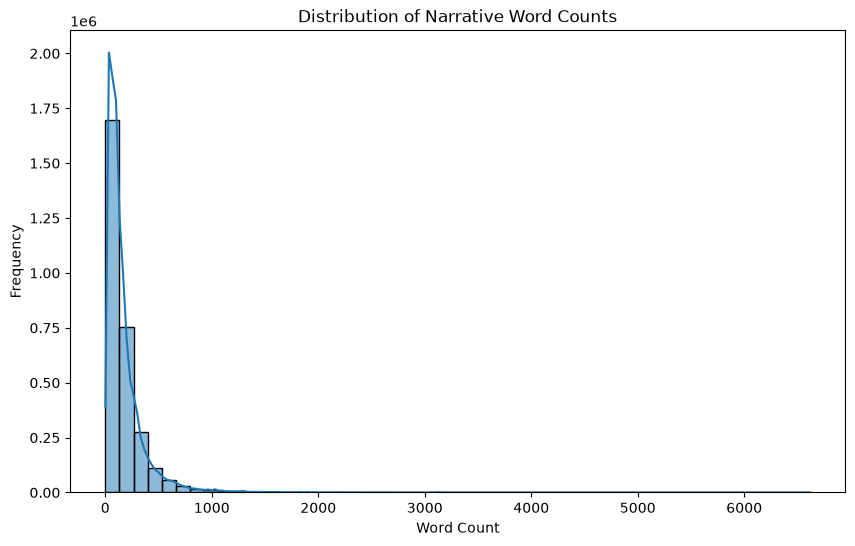

statistic,word_count
str,f64
"""count""",2.980756e6
"""null_count""",6.629041e6
"""mean""",175.865631
"""std""",226.094433
"""min""",1.0
"""25%""",59.0
"""50%""",114.0
"""75%""",210.0
"""max""",6617.0


In [10]:
ie.analyze_narrative_lengths()

In [11]:
ie.count_narrative_presence()


Narrative Presence Summary:
shape: (1, 2)
┌─────────┬─────────┐
│ missing ┆ present │
│ ---     ┆ ---     │
│ u32     ┆ u32     │
╞═════════╪═════════╡
│ 6629041 ┆ 2980756 │
└─────────┴─────────┘


missing,present
u32,u32
6629041,2980756


In [12]:
ie.clean_data()

2026-06-20 19:17:13,538 - INFO - Data cleaned. New shape: (464010, 20)


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,Product_Category
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,u32,str
"""2025-06-13""","""Credit card""","""Store credit card""","""Getting a credit card""","""Card opened without my consent or knowledge""","""A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX that an acc…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78230""","""Servicemember""","""Consent provided""","""Web""","""2025-06-13""","""Closed with non-monetary relief""","""Yes""",null,14069121,92,"""Credit Card"""
"""2025-06-13""","""Checking or savings account""","""Checking account""","""Managing an account""","""Deposits and withdrawals""","""I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outsi…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""WELLS FARGO & COMPANY""","""ID""","""83815""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with explanation""","""Yes""",null,14061897,109,"""Savings Account"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Other features, terms, or problems""","""Other problem""","""Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I have …","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""NY""","""11220""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with monetary relief""","""Yes""",null,14047085,154,"""Credit Card"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Incorrect information on your report""","""Account information incorrect""","""I have a Citi rewards cards. The credit balance issued to me was {$8400.00}. I recently moved, which…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""IL""","""60067""",null,"""Consent provided""","""Web""","""2025-06-12""","""Closed with explanation""","""Yes""",null,14040217,233,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem with a purchase shown on your statement""","""Credit card company isn't resolving a dispute about a purchase on your statement""","""b'I am writing to dispute the following charges on my CITI Credit Card Accounts where I have become …","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78413""","""Older American""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",null,13968411,456,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem when making payments""","""Problem during payment process""","""Although the account had been deemed closed, I continued to make payments towards the dept, however,…","""Company believes it acted appropriately as authorized by contract or law""","""Atlanticus Services Corporation""","""NY""","""11212""","""Older American""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",null,13965746,170,"""Credit Card"""
"""2025-06-08""","""Checking or savings account""","""Checking account""","""Managing an account""","""Problem accessing account""","""Got locked out of my account because I was trying to link my bank account to my XXXX and called cust…","""Company has responded to the consumer and the CFPB and chooses not 

In [13]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64), ('word_count', UInt32), ('Product_Category', String)])


The missing data

shape: (20, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 20619    │
│ Iss

In [14]:
cleaned=ie.clean_narratives_text()

2026-06-20 19:17:23,081 - INFO - Narratives successfully cleaned and normalized.



--- NLP EDA: Cleaned Data ---

[Class Balance]
 shape: (4, 2)
┌──────────────────┬────────┐
│ Product_Category ┆ len    │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ Credit Card      ┆ 197126 │
│ Savings Account  ┆ 140319 │
│ Money Transfer   ┆ 98685  │
│ Personal Loan    ┆ 27880  │
└──────────────────┴────────┘

Total Unique Vocabulary Size: 236184
Potential Outliers (<5 or >1000 words): 5762


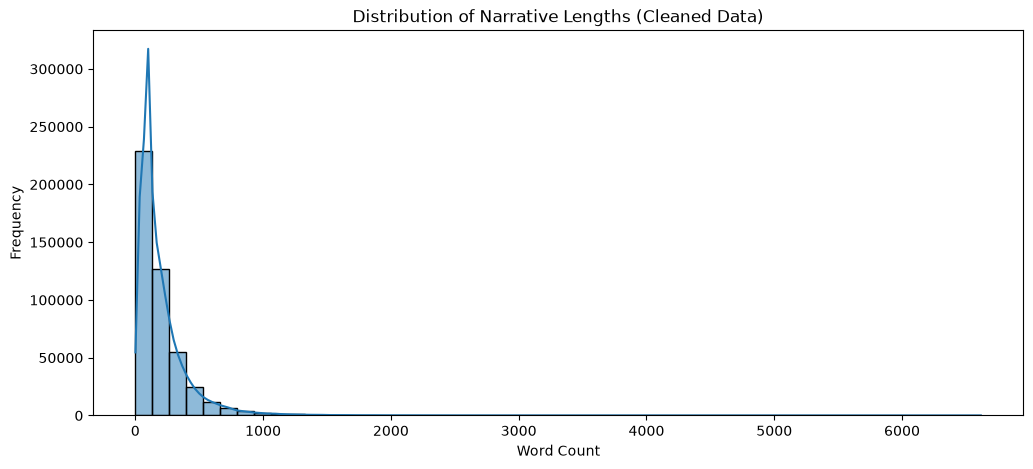

In [15]:
ie.perform_text_eda(stage_name='Cleaned Data')

In [16]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64), ('word_count', UInt32), ('Product_Category', String)])


The missing data

shape: (20, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 20619    │
│ Iss

In [17]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Tags', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Consumer disputed?', String), ('Complaint ID', Int64), ('word_count', UInt32), ('Product_Category', String)])


The missing data

shape: (20, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 20619    │
│ Iss

In [18]:
ie.impute_metadata()

2026-06-20 19:18:06,085 - INFO - Metadata imputed.


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,word_count,Product_Category
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,u32,str
"""2025-06-13""","""Credit card""","""Store credit card""","""Getting a credit card""","""Card opened without my consent or knowledge""","""a card was opened under my name by a fraudster. i received a notice from that an account was just op…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78230""","""Servicemember""","""Consent provided""","""Web""","""2025-06-13""","""Closed with non-monetary relief""","""Yes""",null,14069121,92,"""Credit Card"""
"""2025-06-13""","""Checking or savings account""","""Checking account""","""Managing an account""","""Deposits and withdrawals""","""i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their …","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""WELLS FARGO & COMPANY""","""ID""","""83815""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with explanation""","""Yes""",null,14061897,109,"""Savings Account"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Other features, terms, or problems""","""Other problem""","""i have a secured credit card with citibank which is changed to unsecured card and i have been callin…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""NY""","""11220""",null,"""Consent provided""","""Web""","""2025-06-13""","""Closed with monetary relief""","""Yes""",null,14047085,154,"""Credit Card"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Incorrect information on your report""","""Account information incorrect""","""i have a citi rewards cards. the credit balance issued to me was 8400.00. i recently moved which mea…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""IL""","""60067""",null,"""Consent provided""","""Web""","""2025-06-12""","""Closed with explanation""","""Yes""",null,14040217,233,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem with a purchase shown on your statement""","""Credit card company isn't resolving a dispute about a purchase on your statement""","""bi am writing to dispute the following charges on my citi credit card accounts where i have become a…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78413""","""Older American""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",null,13968411,456,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem when making payments""","""Problem during payment process""","""although the account had been deemed closed i continued to make payments towards the dept however th…","""Company believes it acted appropriately as authorized by contract or law""","""Atlanticus Services Corporation""","""NY""","""11212""","""Older American""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",null,13965746,170,"""Credit Card"""
"""2025-06-08""","""Checking or savings account""","""Checking account""","""Managing an account""","""Problem accessing account""","""got locked out of my account because i was trying to link my bank account to my and called customary…","""Company has responded to the consumer and the CFPB and chooses not

In [19]:
ie.prepare_metadata()

2026-06-20 19:18:13,648 - INFO - Metadata standardized for RAG indexing.


Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID,word_count,Product_Category
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,u32,str
"""2025-06-13""","""Credit card""","""Store credit card""","""Getting a credit card""","""Card opened without my consent or knowledge""","""a card was opened under my name by a fraudster. i received a notice from that an account was just op…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78230""","""Consent provided""","""Web""","""2025-06-13""","""Closed with non-monetary relief""","""Yes""",14069121,92,"""Credit Card"""
"""2025-06-13""","""Checking or savings account""","""Checking account""","""Managing an account""","""Deposits and withdrawals""","""i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside their …","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""WELLS FARGO & COMPANY""","""ID""","""83815""","""Consent provided""","""Web""","""2025-06-13""","""Closed with explanation""","""Yes""",14061897,109,"""Savings Account"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Other features, terms, or problems""","""Other problem""","""i have a secured credit card with citibank which is changed to unsecured card and i have been callin…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""NY""","""11220""","""Consent provided""","""Web""","""2025-06-13""","""Closed with monetary relief""","""Yes""",14047085,154,"""Credit Card"""
"""2025-06-12""","""Credit card""","""General-purpose credit card or charge card""","""Incorrect information on your report""","""Account information incorrect""","""i have a citi rewards cards. the credit balance issued to me was 8400.00. i recently moved which mea…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""IL""","""60067""","""Consent provided""","""Web""","""2025-06-12""","""Closed with explanation""","""Yes""",14040217,233,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem with a purchase shown on your statement""","""Credit card company isn't resolving a dispute about a purchase on your statement""","""bi am writing to dispute the following charges on my citi credit card accounts where i have become a…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""TX""","""78413""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",13968411,456,"""Credit Card"""
"""2025-06-09""","""Credit card""","""General-purpose credit card or charge card""","""Problem when making payments""","""Problem during payment process""","""although the account had been deemed closed i continued to make payments towards the dept however th…","""Company believes it acted appropriately as authorized by contract or law""","""Atlanticus Services Corporation""","""NY""","""11212""","""Consent provided""","""Web""","""2025-06-09""","""Closed with monetary relief""","""Yes""",13965746,170,"""Credit Card"""
"""2025-06-08""","""Checking or savings account""","""Checking account""","""Managing an account""","""Problem accessing account""","""got locked out of my account because i was trying to link my bank account to my and called customary…","""Company has responded to the consumer and the CFPB and chooses not to provide a public response""","""CITIBANK, N.A.""","""MI""","""49401""","""Consent provided""","""Web""","""2025-06-08""","""Closed with

In [20]:
ie.data_summary()

The data types/schema of the Dataframe 

Schema([('Date received', String), ('Product', String), ('Sub-product', String), ('Issue', String), ('Sub-issue', String), ('Consumer complaint narrative', String), ('Company public response', String), ('Company', String), ('State', String), ('ZIP code', String), ('Consumer consent provided?', String), ('Submitted via', String), ('Date sent to company', String), ('Company response to consumer', String), ('Timely response?', String), ('Complaint ID', Int64), ('word_count', UInt32), ('Product_Category', String)])


The missing data

shape: (18, 2)
┌──────────────────────────────┬──────────┐
│ column                       ┆ column_0 │
│ ---                          ┆ ---      │
│ str                          ┆ u32      │
╞══════════════════════════════╪══════════╡
│ Date received                ┆ 0        │
│ Product                      ┆ 0        │
│ Sub-product                  ┆ 0        │
│ Issue                        ┆ 0        │
│ Sub-issue

In [21]:
ie.save_csv(filename='filtered_complaints.csv')

2026-06-20 19:18:22,412 - INFO - Successfully saved cleaned data to: ../data/processed/filtered_complaints.csv




### **CFPB Data Preprocessing & EDA Insights**

An initial assessment of the raw Consumer Financial Protection Bureau (CFPB) dataset revealed a massive, highly unaligned volume of complaints totaling **9,609,797 records** across 21 raw product varieties. A significant challenge identified for text analytics and Retrieval-Augmented Generation (RAG) configuration was the heavy sparsity of consumer-authored text; **6,629,041 records completely lacked text narratives**, meaning only about 31% of the overall complaints contained usable textual records. Furthermore, the native `Product` feature suffered from fragmented categorization (such as separate classes for *"Credit card"* vs. *"Credit card or prepaid card"*), with the overall data heavily skewed toward credit reporting products, which dominated millions of rows.

To align the data for a clean RAG pipeline, downstream filtering strictly isolated four core transaction pillars: **Credit Card, Savings Account, Money Transfer, and Personal Loan**, while dropping all entries with null narratives. This subsetting resulted in a consolidated and refined dataset of **464,010 high-quality consumer text entries**. Within this targeted ecosystem, a distinct class imbalance emerged: **Credit Cards** represented the dominant category with 197,126 complaints, followed closely by **Savings Accounts** (140,319) and **Money Transfers** (98,685), while **Personal Loans** formed a highly minor class with only 27,880 entries.

Textual analysis after stripping standard legal boilerplate, greetings, metadata markers (e.g., *"dear cfpb"*, *"xxxx"* masking), and punctuation revealed a robust vocabulary containing **236,184 unique tokens**. Consumer narratives displayed highly variable reporting behavior; before normalization, the average narrative length stood at approximately **176 words**, though heavily right-skewed with a median of 114 words and an extreme ceiling stretching up to a 6,617-word text block. Post-cleaning length evaluations surfaced **5,762 potential outlier complaints** that contained either extremely trivial descriptions (fewer than 5 words) or massive, repetitive diatribes (exceeding 1,000 words). These highly compressed or bloated narratives may require length-truncation filters or custom chunking thresholds to optimize embedding performance and avoid context window pollution during future RAG system prompting.